In [1]:
# import shutil, os

# src = ""  # ← update slug
# dst = "/kaggle/working/dataprocessing.py"
# shutil.copy(src, dst)
# print("Copied dataprocessing.py →", dst)

In [2]:
# ════════════════════════════════════════════════════════════════════
# CELL 1 — Imports & Configuration
# ════════════════════════════════════════════════════════════════════
import os, sys, random, csv
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import cv2
from PIL import Image
from tqdm.auto import tqdm
from torch.amp import GradScaler, autocast
from torch.utils.data import Dataset, DataLoader
 
sys.path.append("/kaggle/input/datasets/kaisthasagar/dataprocessingv2")
from dataprocessing import CULaneDataset
 

In [3]:
# ── constants ──────────────────────────────────────────────────────
ROOT       = "/kaggle/input/datasets/manideep1108/culane/CULane"
WORK_DIR   = "/kaggle/working"
CKPT_DIR   = os.path.join(WORK_DIR, "checkpoints")
os.makedirs(CKPT_DIR, exist_ok=True)
 
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE  = 32
NUM_WORKERS = 4
EPOCHS      = 20
LR          = 1e-3
TRAIN_FRAC  = 1
VAL_FRAC    = 1
SEED        = 42
 
print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Device : cuda
PyTorch: 2.10.0+cu128


In [4]:
# ════════════════════════════════════════════════════════════════════
# CELL 2 — Model
# ════════════════════════════════════════════════════════════════════
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)
 
 
class LightweightCNN(nn.Module):
    """3-encoder-block CNN with bilinear upsampling. Input/output: [B,3,256,512]."""
    def __init__(self):
        super().__init__()
        self.enc1  = ConvBlock(3,   32);  self.pool1 = nn.MaxPool2d(2)
        self.enc2  = ConvBlock(32,  64);  self.pool2 = nn.MaxPool2d(2)
        self.enc3  = ConvBlock(64, 128)
        self.head  = nn.Conv2d(128, 1, 1)
        self._init_weights()
 
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
 
    def forward(self, x):
        x = self.pool1(self.enc1(x))
        x = self.pool2(self.enc2(x))
        x = self.enc3(x)
        return F.interpolate(self.head(x), scale_factor=4,
                             mode="bilinear", align_corners=False)
 
# smoke-test
_m = LightweightCNN().to(DEVICE)
_o = _m(torch.randn(2, 3, 256, 512).to(DEVICE))
assert _o.shape == (2, 1, 256, 512), f"Unexpected output shape: {_o.shape}"
print(f"Output shape : {tuple(_o.shape)}  ✓")
print(f"Parameters   : {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}")
del _m, _o

Output shape : (2, 1, 256, 512)  ✓
Parameters   : 93,601


In [5]:
# ════════════════════════════════════════════════════════════════════
# CELL 3 — Loss & Metrics
# ════════════════════════════════════════════════════════════════════
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
 
    def forward(self, logits, targets):
        p = torch.sigmoid(logits).squeeze(1)
        t = targets.float()
        inter = (p * t).sum(dim=(1, 2))
        union = p.sum(dim=(1, 2)) + t.sum(dim=(1, 2))
        return (1 - (2 * inter + self.smooth) / (union + self.smooth)).mean()
 
 
class CombinedLoss(nn.Module):
    def __init__(self, pos_weight=10.0, alpha=0.5):
        super().__init__()
        self.dice  = DiceLoss()
        self.alpha = alpha
        self.register_buffer("pw", torch.tensor([pos_weight]))
 
    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits.squeeze(1), targets.float(),
            pos_weight=self.pw.to(logits.device))
        return self.alpha * bce + (1 - self.alpha) * self.dice(logits, targets)
 
 
@torch.no_grad()
def batch_metrics(logits, targets, thr=0.5):
    """Returns (iou, f1) averaged over a batch. Expects raw logits."""
    pred = (torch.sigmoid(logits).squeeze(1) > thr).long()
    tgt  = targets.long()
    tp   = ( pred &  tgt.bool()).float().sum(dim=(1, 2))
    fp   = ( pred & ~tgt.bool()).float().sum(dim=(1, 2))
    fn   = (~pred.bool() &  tgt.bool()).float().sum(dim=(1, 2))
    iou  = (tp + 1e-6) / (tp + fp + fn + 1e-6)
    prec = (tp + 1e-6) / (tp + fp + 1e-6)
    rec  = (tp + 1e-6) / (tp + fn + 1e-6)
    f1   = 2 * prec * rec / (prec + rec + 1e-6)
    return iou.mean().item(), f1.mean().item()

In [6]:
# ════════════════════════════════════════════════════════════════════
# CELL 4 — Data: subsample list files + fast dataloaders
# ════════════════════════════════════════════════════════════════════
random.seed(SEED)
 
def subsample_list(src, dst, fraction):
    with open(src) as f:
        lines = [l for l in f if l.strip()]
    k = max(1, int(len(lines) * fraction))
    with open(dst, "w") as f:
        f.writelines(random.sample(lines, k))
    print(f"  {os.path.basename(src)}: {len(lines):,} → {k:,}  →  {dst}")
 
TRAIN_LIST = os.path.join(WORK_DIR, "train_sub.txt")
VAL_LIST   = os.path.join(WORK_DIR, "val_sub.txt")
 
subsample_list(os.path.join(ROOT, "list/list/train_gt.txt"), TRAIN_LIST, TRAIN_FRAC)
subsample_list(os.path.join(ROOT, "list/list/val_gt.txt"),   VAL_LIST,   VAL_FRAC)
 
 
def make_loader(dataset, batch_size, shuffle, drop_last=False):
    return DataLoader(
        dataset, batch_size=batch_size, shuffle=shuffle,
        num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(),
        drop_last=drop_last, persistent_workers=True, prefetch_factor=4,
    )
 
train_ds = CULaneDataset(ROOT, TRAIN_LIST, augment=True)
val_ds   = CULaneDataset(ROOT, VAL_LIST,   augment=False)
train_loader = make_loader(train_ds, BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = make_loader(val_ds,   BATCH_SIZE, shuffle=False)
 
print(f"Train: {len(train_ds):,} samples → {len(train_loader):,} batches")
print(f"Val  : {len(val_ds):,}   samples → {len(val_loader):,}   batches")

  train_gt.txt: 88,880 → 88,880  →  /kaggle/working/train_sub.txt
  val_gt.txt: 9,675 → 9,675  →  /kaggle/working/val_sub.txt
[Dataset] Detected double-nested structure (e.g. driver_193_90frame/driver_193_90frame/)
[Dataset] Loaded 88,880 samples from train_sub.txt
[Dataset] Detected double-nested structure (e.g. driver_193_90frame/driver_193_90frame/)
[Dataset] Loaded 9,675 samples from val_sub.txt
Train: 88,880 samples → 2,777 batches
Val  : 9,675   samples → 303   batches


In [7]:
# ════════════════════════════════════════════════════════════════════
# CELL 5 — Train / Eval helpers
# ════════════════════════════════════════════════════════════════════
def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    total_loss = 0.0
    pbar = tqdm(loader, desc="  Train", leave=False, dynamic_ncols=True)
    for imgs, masks, _ in pbar:
        imgs  = imgs.to(DEVICE,  non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with autocast("cuda"):
            loss = criterion(model(imgs), masks)
        scaler.scale(loss).backward()
        scaler.step(optimizer); scaler.update()
        total_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")
    return total_loss / len(loader)
 
 
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    tot_loss = tot_iou = tot_f1 = 0.0
    for imgs, masks, _ in loader:
        imgs  = imgs.to(DEVICE,  non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)
        with autocast("cuda"):
            preds = model(imgs)
        tot_loss += criterion(preds, masks).item()
        iou, f1   = batch_metrics(preds, masks)
        tot_iou  += iou;  tot_f1 += f1
    n = len(loader)
    return tot_loss / n, tot_iou / n, tot_f1 / n

In [8]:
# ════════════════════════════════════════════════════════════════════
# CELL 6 — Training loop
# ════════════════════════════════════════════════════════════════════
model     = LightweightCNN().to(DEVICE)
criterion = CombinedLoss(pos_weight=10.0, alpha=0.5).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
scaler    = GradScaler("cuda")
 
best_iou = 0.0
history  = {"epoch": [], "train_loss": [], "val_loss": [],
            "val_iou": [], "val_f1": [], "lr": []}
 
for epoch in range(1, EPOCHS + 1):
    lr_now = optimizer.param_groups[0]["lr"]
    print(f"\nEpoch {epoch}/{EPOCHS}  lr={lr_now:.2e}")
 
    t_loss               = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
    v_loss, v_iou, v_f1  = evaluate(model, val_loader, criterion)
    scheduler.step(v_loss)
 
    history["epoch"].append(epoch)
    history["train_loss"].append(t_loss)
    history["val_loss"].append(v_loss)
    history["val_iou"].append(v_iou)
    history["val_f1"].append(v_f1)
    history["lr"].append(lr_now)
 
    print(f"  train_loss={t_loss:.4f}  val_loss={v_loss:.4f}"
          f"  val_iou={v_iou:.4f}  val_f1={v_f1:.4f}")
 
    if v_iou > best_iou:
        best_iou = v_iou
        torch.save({
            "epoch": epoch, "val_iou": v_iou, "val_f1": v_f1,
            "model_state": model.state_dict(),
            "optim_state": optimizer.state_dict(),
        }, os.path.join(CKPT_DIR, "lightweight_cnn_best.pth"))
        print(f"  ✓ Checkpoint saved  (iou={best_iou:.4f})")
 
print(f"\nTraining complete.  Best val IoU: {best_iou:.4f}")


Epoch 1/20  lr=1.00e-03


  Train:   0%|          | 0/2777 [00:00<?, ?it/s]

  train_loss=0.7040  val_loss=0.7071  val_iou=0.1648  val_f1=0.2706
  ✓ Checkpoint saved  (iou=0.1648)

Epoch 2/20  lr=1.00e-03


  Train:   0%|          | 0/2777 [00:00<?, ?it/s]

  train_loss=0.6619  val_loss=0.7032  val_iou=0.1421  val_f1=0.2416

Epoch 3/20  lr=1.00e-03


...

  train_loss=0.6091  val_loss=0.6406  val_iou=0.2050  val_f1=0.3278

Epoch 19/20  lr=2.50e-04


  Train:   0%|          | 0/2777 [00:00<?, ?it/s]

  train_loss=0.6067  val_loss=0.6321  val_iou=0.2015  val_f1=0.3236

Epoch 20/20  lr=2.50e-04


  Train:   0%|          | 0/2777 [00:00<?, ?it/s]

  train_loss=0.6064  val_loss=0.6314  val_iou=0.1985  val_f1=0.3201

Training complete.  Best val IoU: 0.2075


Training history saved → /kaggle/working/training_history.csv


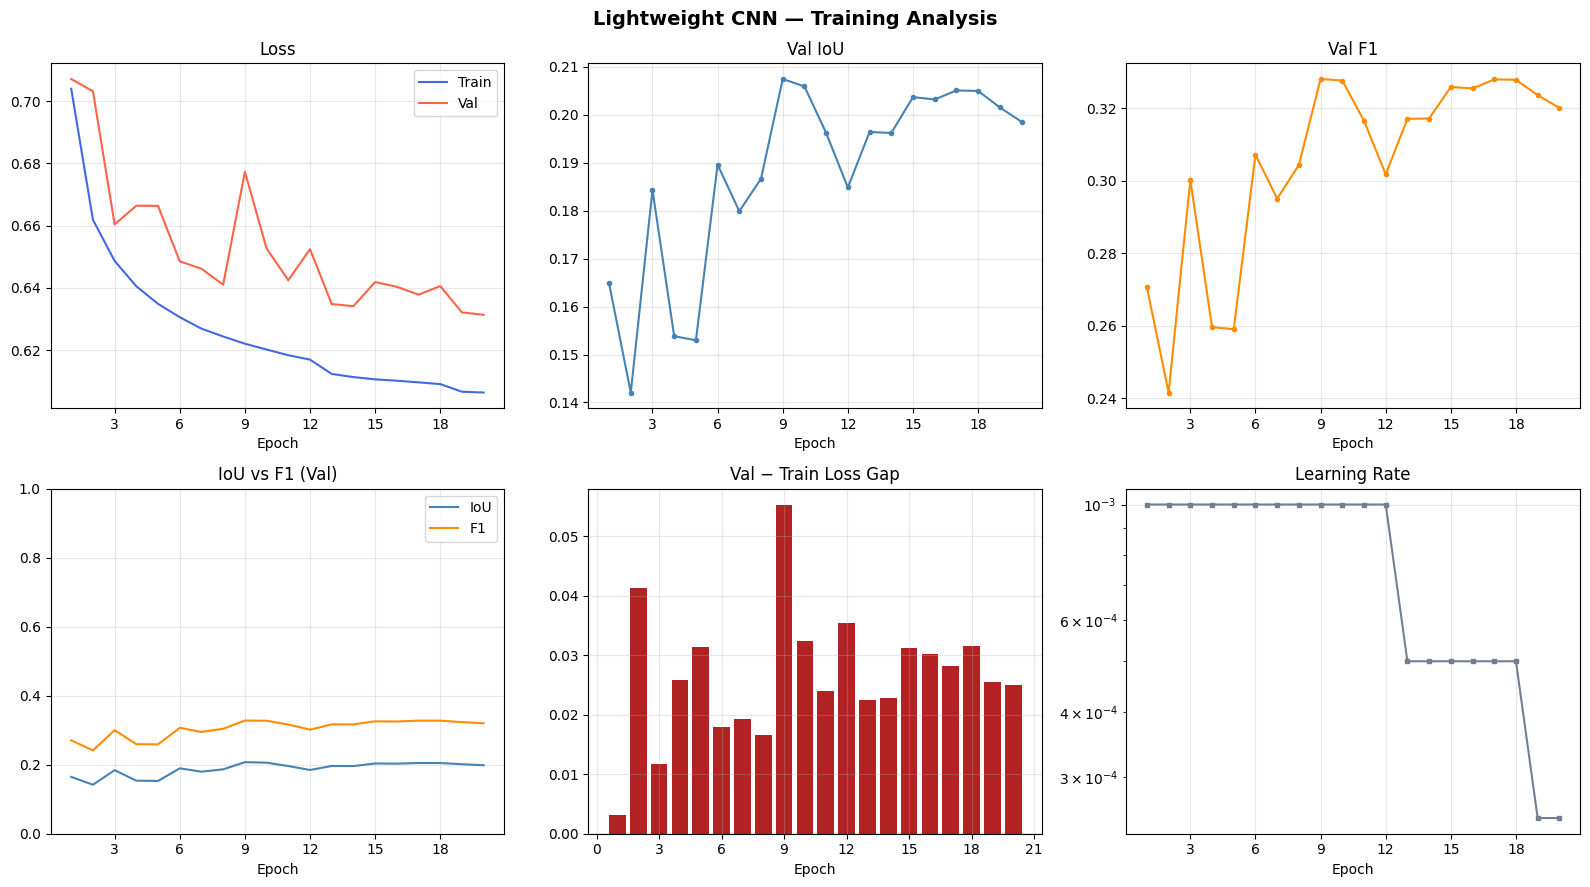

Training curves saved.


In [9]:
# ════════════════════════════════════════════════════════════════════
# CELL 7 — Save training history to CSV
# ════════════════════════════════════════════════════════════════════
TRAIN_CSV = os.path.join(WORK_DIR, "training_history.csv")
with open(TRAIN_CSV, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["epoch", "train_loss", "val_loss",
                                            "val_iou", "val_f1", "lr"])
    writer.writeheader()
    for i in range(len(history["epoch"])):
        writer.writerow({k: history[k][i] for k in writer.fieldnames})
print(f"Training history saved → {TRAIN_CSV}")
 
 
# ════════════════════════════════════════════════════════════════════
# CELL 8 — Training curves (expanded)
# ════════════════════════════════════════════════════════════════════
ep = history["epoch"]
 
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Lightweight CNN — Training Analysis", fontsize=14, fontweight="bold")
 
# 1. Loss curves
axes[0, 0].plot(ep, history["train_loss"], label="Train", color="royalblue")
axes[0, 0].plot(ep, history["val_loss"],   label="Val",   color="tomato")
axes[0, 0].set_title("Loss"); axes[0, 0].legend(); axes[0, 0].set_xlabel("Epoch")
 
# 2. Val IoU
axes[0, 1].plot(ep, history["val_iou"], color="steelblue", marker="o", markersize=3)
axes[0, 1].set_title("Val IoU"); axes[0, 1].set_xlabel("Epoch")
 
# 3. Val F1
axes[0, 2].plot(ep, history["val_f1"], color="darkorange", marker="o", markersize=3)
axes[0, 2].set_title("Val F1"); axes[0, 2].set_xlabel("Epoch")
 
# 4. IoU vs F1 overlay
axes[1, 0].plot(ep, history["val_iou"], label="IoU",  color="steelblue")
axes[1, 0].plot(ep, history["val_f1"],  label="F1",   color="darkorange")
axes[1, 0].set_title("IoU vs F1 (Val)"); axes[1, 0].legend()
axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylim(0, 1)
 
# 5. Train-Val loss gap (generalisation)
gap = [v - t for t, v in zip(history["train_loss"], history["val_loss"])]
axes[1, 1].bar(ep, gap, color=["firebrick" if g > 0 else "seagreen" for g in gap])
axes[1, 1].axhline(0, color="black", linewidth=0.8)
axes[1, 1].set_title("Val − Train Loss Gap"); axes[1, 1].set_xlabel("Epoch")
 
# 6. Learning rate schedule
axes[1, 2].semilogy(ep, history["lr"], color="slategray", marker="s", markersize=3)
axes[1, 2].set_title("Learning Rate"); axes[1, 2].set_xlabel("Epoch")
 
for ax in axes.flat:
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, "training_curves.png"), dpi=120)
plt.show()
print("Training curves saved.")

In [10]:
# ════════════════════════════════════════════════════════════════════
# CELL 9 — Load best checkpoint + ScenarioTestDataset
# ════════════════════════════════════════════════════════════════════
ckpt = torch.load(os.path.join(CKPT_DIR, "lightweight_cnn_best.pth"),
                  map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
print(f"Loaded checkpoint from epoch {ckpt['epoch']}  (val_iou={ckpt['val_iou']:.4f})")
 
 
class ScenarioTestDataset(Dataset):
    """Reads test-split list files (image path only) and derives mask paths."""
    IMG_H, IMG_W = 256, 512
 
    def __init__(self, root, list_file):
        self.root    = root
        self.samples = self._parse(list_file)
        print(f"  [{os.path.basename(list_file)}] {len(self.samples):,} samples with masks")
 
    def _parse(self, list_file):
        samples = []
        with open(list_file) as f:
            for line in f:
                rel = line.strip().lstrip("/")
                if not rel:
                    continue
    
                # image: apply double-nested driver folder via resolve
                img_path = self._resolve(rel)
    
                # mask: laneseg_label_w16_test double-nested (no driver nesting needed)
                mask_path = os.path.join(
                    self.root, "laneseg_label_w16_test",
                    "laneseg_label_w16_test", rel.replace(".jpg", ".png"))
    
                if os.path.exists(img_path) and os.path.exists(mask_path):
                    samples.append((img_path, mask_path))
        return samples

    def _resolve(self, rel):
        """Handle double-nested driver folder structure."""
        driver_folder = rel.split("/")[0]  # e.g. 'driver_100_30frame'
        nested_root   = os.path.join(self.root, driver_folder, driver_folder)
        if os.path.exists(nested_root):
            remainder = "/".join(rel.split("/")[1:])
            return os.path.join(nested_root, remainder)
        return os.path.join(self.root, rel)
 
    def __len__(self):
        return len(self.samples)
 
    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]
        img = cv2.imread(img_path)
        if img is None:
            img  = np.zeros((self.IMG_H, self.IMG_W, 3), dtype=np.uint8)
            mask = np.zeros((self.IMG_H, self.IMG_W),    dtype=np.uint8)
        else:
            img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            mask = np.array(Image.open(mask_path))
            img  = cv2.resize(img,  (self.IMG_W, self.IMG_H), interpolation=cv2.INTER_LINEAR)
            mask = cv2.resize(mask, (self.IMG_W, self.IMG_H), interpolation=cv2.INTER_NEAREST)
            mask = (mask > 0).astype(np.uint8)
        img  = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        mask = torch.from_numpy(mask.copy()).long()
        return img, mask
 
 
@torch.no_grad()
def eval_scenario(model, list_file, root):
    ds = ScenarioTestDataset(root, list_file)
    if len(ds) == 0:
        return None, None
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
    model.eval()
    tot_iou = tot_f1 = 0.0
    pbar = tqdm(loader, desc="    Eval", leave=False, ncols=80)
    for imgs, masks in pbar:
        imgs  = imgs.to(DEVICE,  non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)
        with autocast("cuda"):
            preds = model(imgs)
        iou, f1  = batch_metrics(preds, masks)
        tot_iou += iou;  tot_f1 += f1
        pbar.set_postfix(iou=f"{iou:.3f}", f1=f"{f1:.3f}")
    n = len(loader)
    return tot_iou / n, tot_f1 / n

Loaded checkpoint from epoch 9  (val_iou=0.2075)


In [11]:
# ════════════════════════════════════════════════════════════════════
# CELL 10 — Per-scenario evaluation
# ════════════════════════════════════════════════════════════════════
SCENARIOS = {
    "Normal"      : "test0_normal.txt",
    "Crowded"     : "test1_crowd.txt",
    "Highlight"   : "test2_hlight.txt",
    "Shadow"      : "test3_shadow.txt",
    "No line"     : "test4_noline.txt",
    "Arrow"       : "test5_arrow.txt",
    "Curve"       : "test6_curve.txt",
    "Intersection": "test7_cross.txt",
    "Night"       : "test8_night.txt",
}
 
results = {}
 
print("\n" + "─" * 52)
print(f"{'Scenario':<16} {'IoU':>8} {'F1':>8}  F1 bar")
print("─" * 52)
 
for name, fname in tqdm(SCENARIOS.items(), desc="Scenarios", ncols=80):
    list_path = os.path.join(ROOT, "list", "list", "test_split", fname)
    if not os.path.exists(list_path):
        tqdm.write(f"{name:<16}  list file not found, skipping"); continue
    iou, f1 = eval_scenario(model, list_path, ROOT)
    if iou is None:
        tqdm.write(f"{name:<16}  (no masked samples)"); continue
    results[name] = {"iou": iou, "f1": f1}
    tqdm.write(f"{name:<16} {iou:>8.4f} {f1:>8.4f}  {'█' * int(f1 * 20)}")
 
avg_iou = sum(v["iou"] for v in results.values()) / len(results)
avg_f1  = sum(v["f1"]  for v in results.values()) / len(results)
print("─" * 52)
print(f"{'Mean':<16} {avg_iou:>8.4f} {avg_f1:>8.4f}")


────────────────────────────────────────────────────
Scenario              IoU       F1  F1 bar
────────────────────────────────────────────────────


Scenarios:   0%|                                          | 0/9 [00:00<?, ?it/s]

  [test0_normal.txt] 9,621 samples with masks


    Eval:   0%|                                         | 0/301 [00:00<?, ?it/s]

Normal             0.3315   0.4862  █████████
  [test1_crowd.txt] 8,113 samples with masks


...

Curve              0.2758   0.4195  ████████
  [test7_cross.txt] 3,122 samples with masks


    Eval:   0%|                                          | 0/98 [00:00<?, ?it/s]

Intersection       0.0000   0.0000  
  [test8_night.txt] 7,029 samples with masks


    Eval:   0%|                                         | 0/220 [00:00<?, ?it/s]

Night              0.1418   0.2369  ████
────────────────────────────────────────────────────
Mean               0.1908   0.3015


In [12]:
# ════════════════════════════════════════════════════════════════════
# CELL 11 — Save per-scenario results to CSV
# ════════════════════════════════════════════════════════════════════
SCENARIO_CSV = os.path.join(WORK_DIR, "scenario_results.csv")
with open(SCENARIO_CSV, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["scenario", "iou", "f1"])
    writer.writeheader()
    for name, vals in results.items():
        writer.writerow({"scenario": name, **vals})
    writer.writerow({"scenario": "Mean", "iou": avg_iou, "f1": avg_f1})
print(f"Scenario results saved → {SCENARIO_CSV}")

Scenario results saved → /kaggle/working/scenario_results.csv


/tmp/ipykernel_23/390018007.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(names, rotation=30, ha="right")


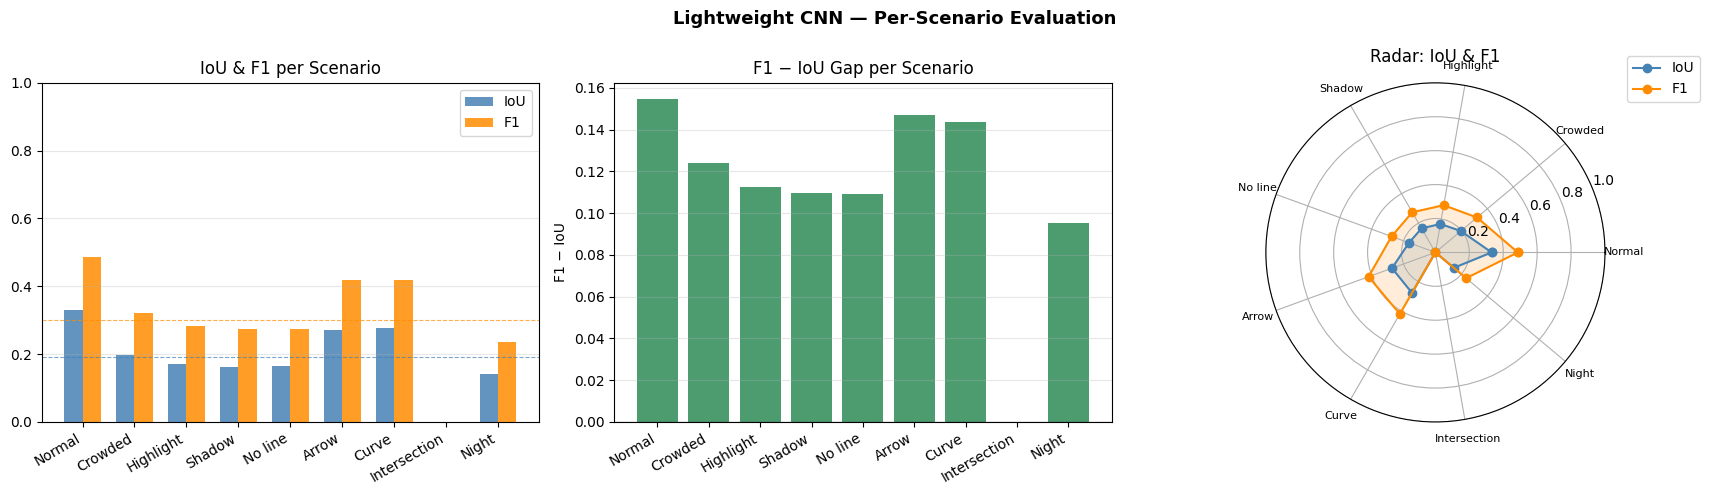

Scenario charts saved.


In [13]:
# ════════════════════════════════════════════════════════════════════
# CELL 12 — Scenario visualisations (3 charts)
# ════════════════════════════════════════════════════════════════════
names = list(results.keys())
ious  = [results[n]["iou"] for n in names]
f1s   = [results[n]["f1"]  for n in names]
x     = np.arange(len(names))
width = 0.35
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Lightweight CNN — Per-Scenario Evaluation", fontsize=13, fontweight="bold")
 
# ── Chart A: grouped bar IoU + F1 ─────────────────────────────────
axes[0].bar(x - width/2, ious, width, label="IoU",  color="steelblue",  alpha=0.85)
axes[0].bar(x + width/2, f1s,  width, label="F1",   color="darkorange", alpha=0.85)
axes[0].axhline(avg_iou, color="steelblue",  linestyle="--", linewidth=0.8, alpha=0.7)
axes[0].axhline(avg_f1,  color="darkorange", linestyle="--", linewidth=0.8, alpha=0.7)
axes[0].set_xticks(x); axes[0].set_xticklabels(names, rotation=30, ha="right")
axes[0].set_ylim(0, 1); axes[0].legend(); axes[0].set_title("IoU & F1 per Scenario")
axes[0].grid(axis="y", alpha=0.3)
 
# ── Chart B: F1 − IoU gap (how well calibrated) ───────────────────
gap = [f - i for i, f in zip(ious, f1s)]
colors = ["seagreen" if g >= 0 else "firebrick" for g in gap]
axes[1].bar(names, gap, color=colors, alpha=0.85)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xticklabels(names, rotation=30, ha="right")
axes[1].set_title("F1 − IoU Gap per Scenario")
axes[1].set_ylabel("F1 − IoU")
axes[1].grid(axis="y", alpha=0.3)
 
# ── Chart C: radar / spider chart ─────────────────────────────────
angles = np.linspace(0, 2 * np.pi, len(names), endpoint=False).tolist()
angles += angles[:1]   # close polygon
iou_vals = ious + ious[:1]
f1_vals  = f1s  + f1s[:1]
 
ax_r = axes[2]
ax_r.remove()
ax_r = fig.add_subplot(1, 3, 3, polar=True)
ax_r.plot(angles, iou_vals, "o-", linewidth=1.5, color="steelblue",  label="IoU")
ax_r.fill(angles, iou_vals, alpha=0.15, color="steelblue")
ax_r.plot(angles, f1_vals,  "o-", linewidth=1.5, color="darkorange", label="F1")
ax_r.fill(angles, f1_vals,  alpha=0.15, color="darkorange")
ax_r.set_xticks(angles[:-1]); ax_r.set_xticklabels(names, size=8)
ax_r.set_ylim(0, 1); ax_r.set_title("Radar: IoU & F1", pad=15)
ax_r.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
 
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, "scenario_eval.png"), dpi=120)
plt.show()
print("Scenario charts saved.")

In [3]:
"""
inference.py — Run the LightweightCNN lane detection model on an image.

This script loads a trained model checkpoint, processes an input image, and outputs
a binary lane mask and an overlay visualization.

This block can be used as a standalone block to run inference on a single image,
given the path to the image and the model weights.

Requirements:
    pip install torch torchvision opencv-python numpy
"""

import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F


# ── Config — edit these paths ────────────────────────────────────────────────────

IMAGE_PATH   = "road.jpg"          # input image
WEIGHTS_PATH = "lightweight_cnn_best.pth"   # model checkpoint
THRESHOLD    = 0.5                           # sigmoid threshold (try 0.3–0.4 for more lanes)
OUT_MASK     = "lane_mask.png"              # output binary mask
OUT_OVERLAY  = "lane_overlay.png"           # output overlay


# ── Model definition ─────────────────────────────────────────────────────────────

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)


class LightweightCNN(nn.Module):
    """3-encoder-block CNN with bilinear upsampling. Input/output: [B, 3, 256, 512]."""
    def __init__(self):
        super().__init__()
        self.enc1 = ConvBlock(3,   32);  self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ConvBlock(32,  64);  self.pool2 = nn.MaxPool2d(2)
        self.enc3 = ConvBlock(64, 128)
        self.head = nn.Conv2d(128, 1, 1)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.pool1(self.enc1(x))
        x = self.pool2(self.enc2(x))
        x = self.enc3(x)
        return F.interpolate(self.head(x), scale_factor=4,
                             mode="bilinear", align_corners=False)


# ── Preprocessing ────────────────────────────────────────────────────────────────

INPUT_W, INPUT_H = 512, 256

def preprocess(image_path: str) -> tuple[torch.Tensor, tuple[int, int]]:
    """Load an image, resize to 512×256, normalise to [0, 1].
    Returns:
        tensor    : [1, 3, 256, 512] float32 ready for the model
        orig_size : (orig_H, orig_W) for resizing the mask back
    """
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")
    orig_size = img.shape[:2]                               # (H, W)
    img = cv2.resize(img, (INPUT_W, INPUT_H))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img.astype(np.float32) / 255.0
    tensor = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0)  # [1, 3, 256, 512]
    return tensor, orig_size


# ── Postprocessing ───────────────────────────────────────────────────────────────

def postprocess(logits: torch.Tensor, orig_size: tuple[int, int],
                threshold: float = 0.5) -> np.ndarray:
    """Convert raw model logits → binary mask resized to the original image size.
    Returns uint8 mask (0 = background, 255 = lane).
    """
    prob   = torch.sigmoid(logits).squeeze().cpu().numpy()  # [256, 512]
    binary = (prob >= threshold).astype(np.uint8) * 255
    orig_H, orig_W = orig_size
    return cv2.resize(binary, (orig_W, orig_H), interpolation=cv2.INTER_NEAREST)


# ── Overlay helper ───────────────────────────────────────────────────────────────

def overlay_mask(image_path: str, mask: np.ndarray,
                 color: tuple = (0, 255, 0), alpha: float = 0.4) -> np.ndarray:
    """Blend the binary lane mask onto the original image in green."""
    img     = cv2.imread(image_path)
    overlay = img.copy()
    overlay[mask > 0] = color
    return cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0)


# ── Run inference ────────────────────────────────────────────────────────────────

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

model = LightweightCNN().to(device)
checkpoint = torch.load(WEIGHTS_PATH, map_location=device)
state_dict = checkpoint["model_state"] if "model_state" in checkpoint else checkpoint
model.load_state_dict(state_dict)
print(f"Epoch: {checkpoint.get('epoch', 'N/A')}  |  Val IoU: {checkpoint.get('val_iou', 'N/A')}  |  Val F1: {checkpoint.get('val_f1', 'N/A')}")
model.eval()
print(f"Loaded : {WEIGHTS_PATH}")

tensor, orig_size = preprocess(IMAGE_PATH)
tensor = tensor.to(device)

with torch.no_grad():
    logits = model(tensor)                      # [1, 1, 256, 512]

mask    = postprocess(logits, orig_size, threshold=THRESHOLD)
overlay = overlay_mask(IMAGE_PATH, mask)

cv2.imwrite(OUT_MASK,    mask)
cv2.imwrite(OUT_OVERLAY, overlay)
print(f"Mask    → {OUT_MASK}")
print(f"Overlay → {OUT_OVERLAY}")
print(f"Lane pixels: {(mask > 0).sum() / mask.size * 100:.2f}% of image")

Device : cpu
Epoch: 9  |  Val IoU: 0.20746733051518795  |  Val F1: 0.3280423191120916
Loaded : lightweight_cnn_best.pth
Mask    → lane_mask.png
Overlay → lane_overlay.png
Lane pixels: 1.50% of image
